In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.display import HTML
from scipy.optimize import curve_fit
from scipy.optimize import differential_evolution
import warnings
import math
import time 

In [2]:
# import csv data to dataframe, find wells that have less than or equal to 5 data points as invalid wells, 
# delete invalid wells, keep valid wells. 
# Outlier detection: if 'oil' is 0, data is considered outlier, filter out the outliers.
def read_and_delete_invalid_data(file_path):
    df = pd.read_csv(file_path)
    df.replace({"JAN": "01", "FEB": "02", "MAR":"03", "APR":"04", "MAY":"05", "JUN":"06", "JUL":"07",
               "AUG":"08", "SEP":"09", "OCT":"10", "NOV":"11", "DEC":"12"}, inplace=True)
    df = df.sort_values(['year', 'month'])
    df1 = df.groupby("API").size()
    invalid_api_list = []
    valid_api_list = []
    for api, count in df1.items():
        if count<=5:
            invalid_api_list.append(str(api))
        else:
            valid_api_list.append(str(api))
    for api in invalid_api_list:
        df.drop(df.loc[df['API']==api].index, inplace=True)
    df.drop(df.loc[df['oil']==0].index, inplace=True)  # remove the outliner
    return df, valid_api_list

In [3]:
# handling time series data, convert well data into dataframe individually, and store into a list, "well_list"
def divide_and_sort_data(df, valid_api_list):
    well_list=[]
    for api in valid_api_list:
        well = df.loc[df['API'] == api]
        # sort well data based on "year" and "month"
        well = well.sort_values(['year', 'month'])
        # convert "year" and "month" to sequential numbers for each well
        time_series = []
        current_time = 0
        max_time = 0
        for index, row in well.iterrows():
            time_string = str(row['year']) + str(row['month'])
            time_int = int(time_string)
            if max_time == 0:
                max_time = time_int
                time_series.append(current_time)
            elif time_int > max_time:
                max_time = time_int
                current_time = current_time + 1
                time_series.append(current_time)            
            else:
                time_series.append(current_time)
        
        well['time'] = time_series
        well_list.append(well)
    return well_list

### define curve_models

In [4]:
# define production decline curve model as problem stated
def decline_curve_model(tArray, q0, D0, D1, b, t1):
    returnArray = []
    # reset the corner value to avoid overflow or error math domain
    if b == 0:
        b = 1
    if b < 0:
        b = 0.5
    if D1 < 0:
        D1 = 5
    if D0 < 0 or D0 > 250:
        D0 = 0.1
        
    for t in tArray:
        if t < t1:
            returnArray.append(q0 * math.exp(D0 * t))
        else:         
            returnArray.append((q0 * math.exp(D0 * t1))/(math.pow(1 + b * D1 * (t - t1), 1/b)))
            
    return returnArray
    

In [5]:
# Loss function: mean of squared error(MSE). 
# The reason for using MSE: 
# 1. The loss function value should be positive, so we can minimize loss
# 2. This loss function is more differentiable than the sum of absolute error(SAE)
# 3. MSE will decrease when dataset size increases and curve fits better, 
# so it is better than sum of squared error(SSE)
def mean_squared_error(parameterTuple, time, oil):
    warnings.filterwarnings("ignore") # do not print warnings
    val = decline_curve_model(time, *parameterTuple)
    return np.sum((oil - val)**2)/len(time)

In [6]:
# Use differential evolution optimization algorithm to proceed 
def generate_parameters(tArray,yArray):
    # min and max used for t1 bounds
    maxT = max(tArray)
    minT = min(tArray)
    
    parameterBounds = []
    parameterBounds.append([0, 300]) # search bounds for q0
    parameterBounds.append([0,5]) # search bounds for D0
    parameterBounds.append([0, 10]) # search bounds for D1
    parameterBounds.append([0, 1]) # search bounds for b
    parameterBounds.append([minT, maxT]) # search bounds for t1

    result = differential_evolution(mean_squared_error,parameterBounds, args=(tArray, yArray), seed=5)
    return result.x

In [7]:
# fetch time and oil for each well based on index in the well_list
def generate_model_input(index, well_list):
    well = well_list[index]
    time = well['time'].to_numpy()
    oil = well['oil'].to_numpy()
    return time, oil


In [8]:
# Plot actual data points and fitted curve
def ModelAndScatterPlot(tArray, yArray, fittedParameters, graphWidth, graphHeight, index):
    f = plt.figure(figsize=(graphWidth/100.0, graphHeight/100.0), dpi=100)
    axes = f.add_subplot(111)

    # first the raw data as a scatter plot
    axes.plot(tArray, yArray,  'D')

    # create data for the fitted equation plot
    xModel = np.linspace(min(tArray), max(tArray))
    yModel = decline_curve_model(xModel, *fittedParameters)

    # now the model as a line plot
    axes.plot(xModel, yModel)

    axes.set_xlabel('Time') # X axis data label
    axes.set_ylabel('Oil') # Y axis data label
    axes.set_title('Well #{}'.format(index), fontsize = 14)
    
    plt.savefig('Well #{}.jpg'.format(index), fontsize = 14)
    plt.show()
    plt.close('all') # clean up after using pyplot


In [9]:
def main():
    df, valid_api_list = read_and_delete_invalid_data("Project_data.csv")
    well_list = divide_and_sort_data(df, valid_api_list)
    MSE_list=[]
    for index in range(len(well_list)):
        tArray, yArray = generate_model_input(index, well_list)
        fittedParameters = generate_parameters(tArray, yArray)
        
        # Another optioin, 
        # Use differential_evolution to generate initial parameter as a good guess,
        # then use curve_fit to further fit the curve 
        
        # initialParameters = generate_parameters(tArray, yArray)
        # fittedParameters, pcov = curve_fit(decline_curve_model, tArray, yArray, initialParameters,maxfev=20000)
        
        modelPredictions = decline_curve_model(tArray, *fittedParameters) 
        absError = modelPredictions - yArray
        SE = np.square(absError) # squared errors
        MSE = np.mean(SE) # mean squared errors
        
        MSE_list.append(MSE)
        
        # Plot the first 4 wells 
        if index < 4:
            graphWidth = 800
            graphHeight = 600
            ModelAndScatterPlot(tArray, yArray,fittedParameters, graphWidth, graphHeight, index)
    #plot hist of MSE        
    plt.hist(MSE_list, density=False, bins=10)  # density=False would make counts
    plt.ylabel('Count')
    plt.xlabel('MSE')

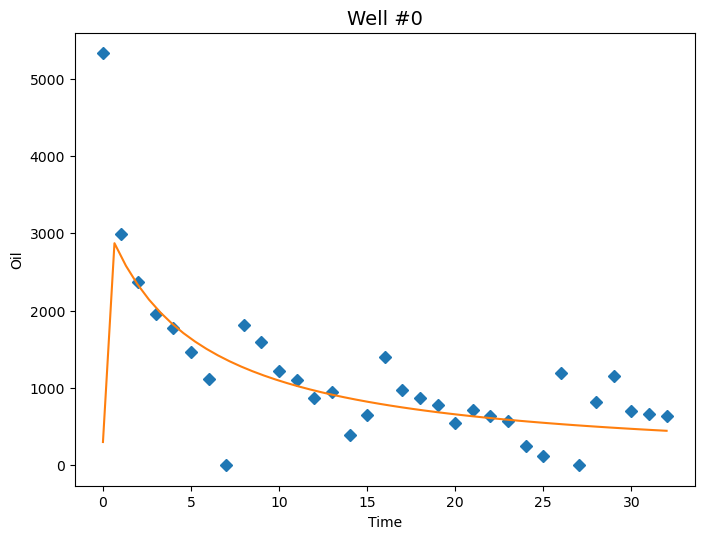

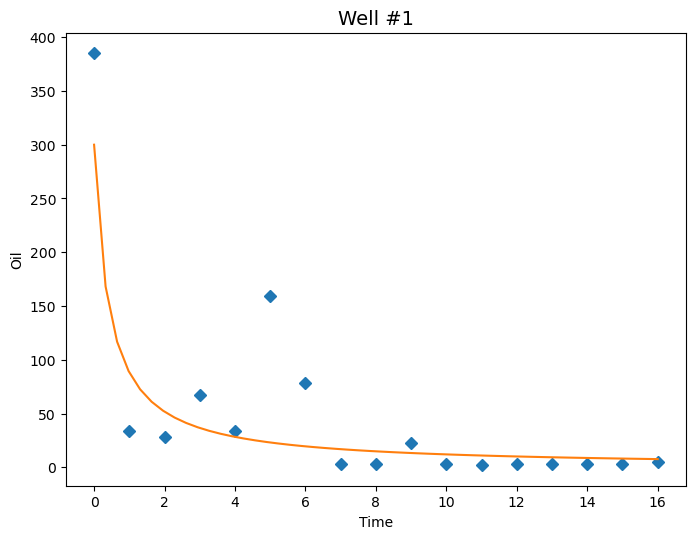

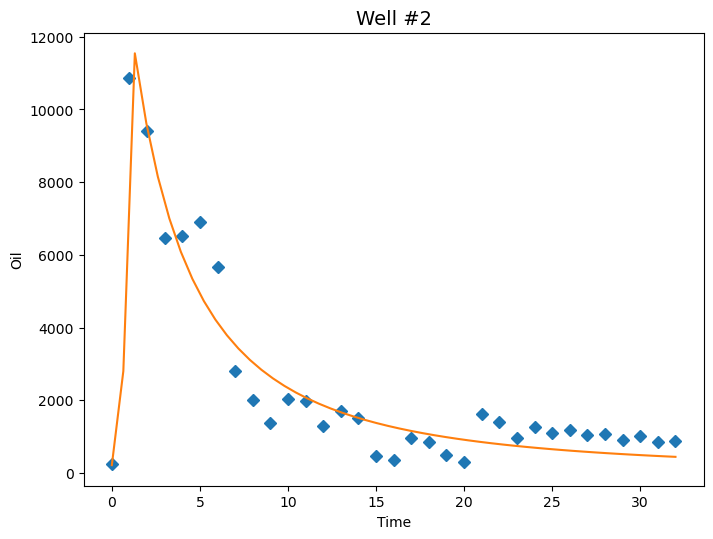

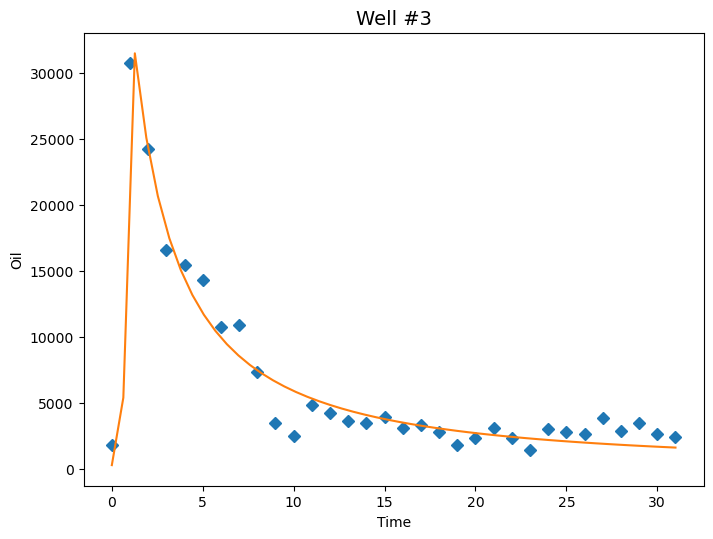

--- 82.36337995529175 seconds are used to run the experiments---


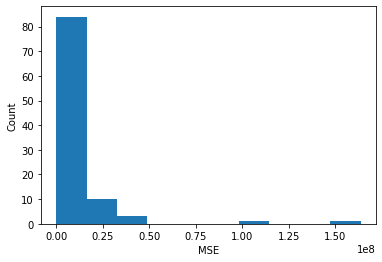

In [10]:
if __name__== "__main__":
    start_time = time.time()
    main()
    print("--- %s seconds are used to run the experiments---" % (time.time() - start_time))